Primer avance de Proyecto Dinamica colectiva no lineal en una Magneto-Optical
Trap (MOT)  
  
Una trampa opto-magnetica es un confinamiento para atomos neutros. Especialmente para estos atomos ya que el campo magnetico producido para confinar a los atomos no produce una fuerza de Lorenz asociada, pero si modifica las energias internas de los atomos, dando lugar al Efecto Zeemann. La MOT depende de campos magneticos no homogeneos, interaccion radiativa, que permite el enfriamiento de estos ya que reducen su movimiento y de las reglas de seleccion radiativas, es decir, que transiciones estan permitidas y entrega una fuerza restauradora al sistema.  
  
Este mecanismo funciona mediante un bombeo optico, que reorganiza la poblacion de los subniveles internos de los atomos que se mueven lentamente en un campo magnetico. En el caso unidimensional se inyectan dos campos o laseres contrapropagantes con polarizaciones circulares opuestas y con una frecuencia cercana a la de la transicion atomica, que permitiria la transicion de entre algunos estados si las frecuencias estan en resonancia. Ademas, estos laseres contrapropagantes, dependiendo de si el atomo esta mas cerca de uno que de otro, induce una fuerza restauradora que en palabras simples, empuja al atomo al centro del confinamiento. Como se menciono anteriormente el campo magnetico desplaza los estados excitados y, dependiendo de la posicion del atomo en el confinamiento espacial, este percibe de distinta manera la distancia entre niveles por este mismo efecto.   
De esta manera se obtiene de manera simultanea la compresion y enfriamiento del atomo.  
  
El objetivo de esta primera parte del informe sera encontrar numericamente la evolucion del estado excitado del sistema y su operador de subida o bajada variando los parametros del acoplamiento y el detuning en una dimension. Para ello utilizaremos las ecuaciones opticas de Bloch. Como primer paso es definir el super operador de Linblad:

$\mathcal{L}(\cdot)=-i[H,\cdot] + \sum_{k}\gamma_{k} [L_{k} \cdot L^{\dagger}_{k}-\frac{1}{2}\{L^{\dagger}_{k}L_{k},\cdot \}] $  
  
Donde $H$ es el hamiltoniano del sistema, $\gamma_{k}$ son las tasas de disipacion del sistema y $L$ los operadores asociados a estas tasas.  

In [ ]:
import numpy as np

def Lindblad(t, matrixdensity_flat, H, Loper, rates):
    dim=H.shape[0]                                         #Entrega la dimension del sistema
    Mdensity=matrixdensity_flat.reshape((dim, dim))        #Convierte el vector de matriz densidad rho su forma matricial

    #Conmutador
    
    C=-1j * (H@Mdensity-Mdensity@H)                        #Conmutador de ecuacion maestra -i[H,rho]

    #Disipacion

    D=np.zeros_like(Mdensity, dtype=complex)               #Crea matriz de ceros con la dimension de la matriz densidad
    for L, gamma in zip(Loper, rates):                     #Ciclo para considerar todas las disipaciones del sistema total
        Ldagger=L.conj().T                                 #Conjuga el operador considerado en el superoperador de Linblad
        D+=gamma*(L@Mdensity@Ldagger)                      #Se agrega pirmer termino disipativo gamma_{k}L_{k}L_{k}^{\dagger}
        D-=0.5*gamma*(Ldagger@L@Mdensity+Mdensity@Ldagger@L)           #Se agrega segundo termino disipativo -\frac{gamma_{k}}{2}{L_{k}^{\dagger}L_{k},rho}

    dmatrixdensity_dt= C+D                                 #Ecuacion maestra
    return dmatrixdensity_dt.flatten()                     #Pasa a vector la forma matricial ya que el integrador que ocuparemos solo trata con vectores [cdot{p_ee}, cdot{p_eg}, cdot{p_ge}, cdot{p_gg}]


El Hamiltoniano del sistema de dos niveles esta dado por:  
  
$H=-\frac{\delta}{2}\sigma_{z} + \frac{1}{2}(\Omega \sigma_{+} + \Omega^{*}\sigma_{-})$  

Donde $\delta=\omega-\omega_{0}$ es el detuning, $\omega$ es la frecuencia del laser y $\omega_{0}$ es la frecuencia natural de transicion del atomo. Ademas $\Omega$ es la frecuencia de Rabi y $\sigma_{z}, \sigma_{+}, \sigma_{-}$ son los operadores de pauli $z$, de subida y bajada, respectivamente. Considerando $\hbar=1$. 

Es importante destacar que a este hamiltoniano se le aplico una aproximacion dipolar electrica, una aproximacion de onda rotante y fue traslado al cuadro rotante con el fin de obtener un mejor analisis del sistema.  

Se definen ademas, las matrices de pauli y los operadores de subida y bajada que nos seran utiles mas adelante:  

$\sigma_x = \begin{pmatrix} 
0 & 1 \\ 
1 & 0
\end{pmatrix}$  

$\sigma_y = \begin{pmatrix} 
0 & -i \\ 
i & 0
\end{pmatrix}$  

$\sigma_z = \begin{pmatrix} 
1 & 0 \\ 
0 & -1
\end{pmatrix}$  

$\sigma_+ = \begin{pmatrix} 
0 & 1 \\ 
0 & 0
\end{pmatrix}$  

$\sigma_- = \begin{pmatrix} 
0 & 0 \\ 
1 & 0
\end{pmatrix}$  

In [2]:
#Operadores

sigma_x=np.array([[0,1],[1,0]], dtype=complex)
sigma_y=np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z=np.array([[1,0],[0,-1]], dtype=complex)
sigma_plus=np.array([[0,1],[0,0]], dtype=complex)
sigma_minus=np.array([[0,0],[1,0]], dtype=complex)

La ecuacion maestra de Linblad describe la evolucion de la matriz densidad de un sistema abierto, considerando tanto la parte del sistema de interes como su interaccion con el medio. En particular, nos interesa como evolucion la matriz densidad de nuestro sistema de dos niveles. Esta ecuacion es tal que:

$\dot{\rho}=-i[H,\rho_{s}]+\gamma_{0}\left( \sigma_{-}\rho \sigma_{+}-\frac{1}{2}\{\sigma_{+}\sigma_{-}, \rho \}\right)$  

Esta ecuacion representa la evolucion temporal de nuestro sistema a temperatura $K=0 considerando una emision espontanea con el medio (el atomo regala una excitacion). El primer termino corresponde a la dinamica cerrada del sistema y el segundo termino a la disipacion que nace de la interaccion con el medio.  

Podriamos resolver esta ecuacion, pero fisicamente no es tan reveladora. Por lo cual tomamos el enfoque de las ecuaciones de movimiento de Bloch que analiza como evolucionan los valores promedio de los operadores $\sigma_{x}, \sigma_{y}, \sigma_{z}$ que representan la parte real e imaginaria de las coherencias y las poblaciones de estado excitado y el fundamental, respectivamente.  

Para esto, sabemos que el valor promedio de cualquier operador tiene la forma:  

$\langle O \rangle = \text{Tr}(\rho O)$    

Con esto en mente lo que haremos sera integrar la ecuacion de linblad y obtener su forma dependiente del tiempo para luego obtener los valores promedios de los operadores de pauli y de subida y bajada. Tambien nos interesa el elemento matricial de la poblacion excitada.

In [ ]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#Variables

w_0=1                                                           #Frecuencia de transicion del atomo
w=w_0                                                           #Frecuencia del laser
delta=w-w_0                                                     #Detuning
Omega=1                                                         #Frecuencia de Rabi
Gamma=0.1*Omega                                                 #Tasa de decaimiento

#Hamiltoniano (consideramos Rabi real)

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x     

#Operadores y tasas para funcion Linblad

Loper=[sigma_minus]                                             #Lista de operadores relevantes de la parte disipativa para el ciclo for de Lindblad
rates=[Gamma]                                                   #Lista de tasas disipativas en el sistema para el ciclo for de Lindbald

#Condicion inicial(p_{gg}=1)

Mdensity_0=np.array([[0,0],[0,1]], dtype=complex).flatten()     #Dinamica comienza en Estado fundamental

#Integrador

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))     #Integrador numerico utilizado, donde solve_ivp(Ecuacion diferencial, dominio integracion, condicion incial, dominio de integracion y cantidad de pasos, argumentos relevantes)

#Solucion, reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)                          #sol.y entrega la solucion de la integracion de la forma (variables, tiempos) y  agregar .T ordena por fila cada instante de tiempo los elementos matriciales (t: [rho_ee, rho_eg, rho_ge, rho_gg]).Luego.reshape(-1, 2, 2) nos devuelve la forma matricial de la evocuion temporal de rho
t = sol.t                                                       #Es el arreglo de tiempos de la integracion

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])        #Aqui lo que hacemos es tomar cada matriz en un instante de tiempo y saca el elemento que queramos. En las primeras dos sacamos la parte real solo porque esos valores sabemos que tienen que ser reales pero la integracion numericas contiene errores minimos que pueden conllevar tener un imaginario en tales elementos
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Poblacion excitada Analitica si detuning (De Laser Cooling and Trapping)

mu = np.sqrt(Omega**2 - (Gamma/4)**2)

def p_ee(t):
    A = (Omega**2) / (Gamma**2 + 2*Omega**2)
    
    return A * ( 1 - np.exp(-3*Gamma*t/4) * (np.cos(mu*t) + (3*Gamma/(4*mu))*np.sin(mu*t)))


y = p_ee(t)

def p_eg(t):
    A = ( -1j*Omega*Gamma ) / ( Gamma**2+ 2*Omega**2)
    
    return A * (1 - np.exp(-3*Gamma*t/4) * (np.cos(mu*t) + ((Gamma/(4*mu))-(Omega**2/(mu*Gamma)))*np.sin(mu*t)))

z = p_eg(t)

Primero queremos saber si el comportamiento numerico converge al teorico. En particular, se conoce la solucion analitica para este caso cuando el $\delta =0$ para diferentes proporciones de $\frac{\gamma_{0}}{\Omega}$. En primer lugar, analizamos el caso donde el acoplamiento es mucho mas fuerte que la disipacion natural del sistema $\frac{\gamma_{0}}{\Omega} = 0.1$:

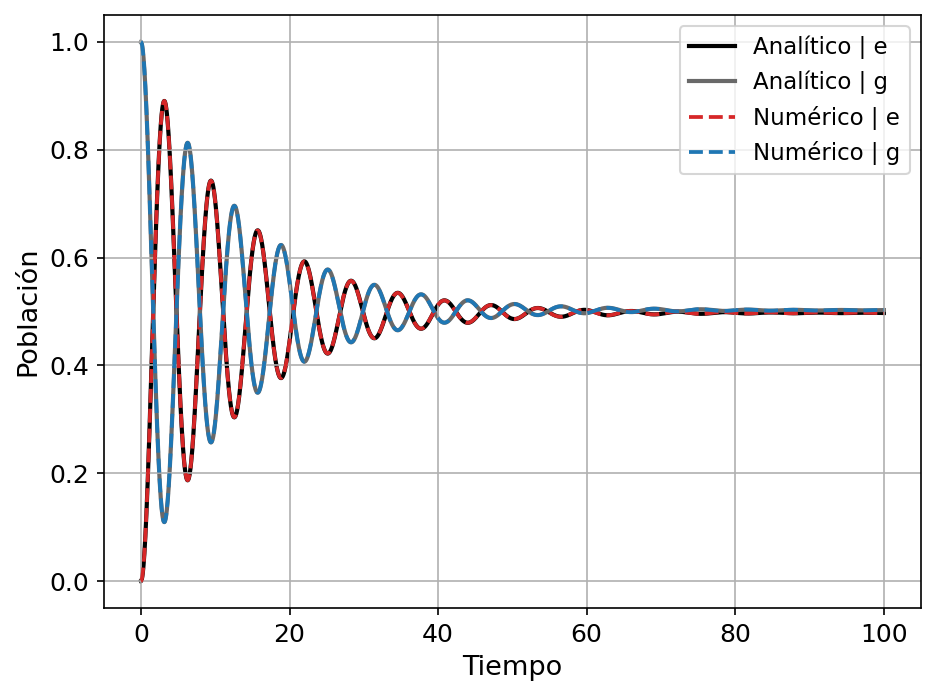


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.497038
Numérico | g: 0.502962
Analítico | e: 0.497291
Analítico | g: 0.502709


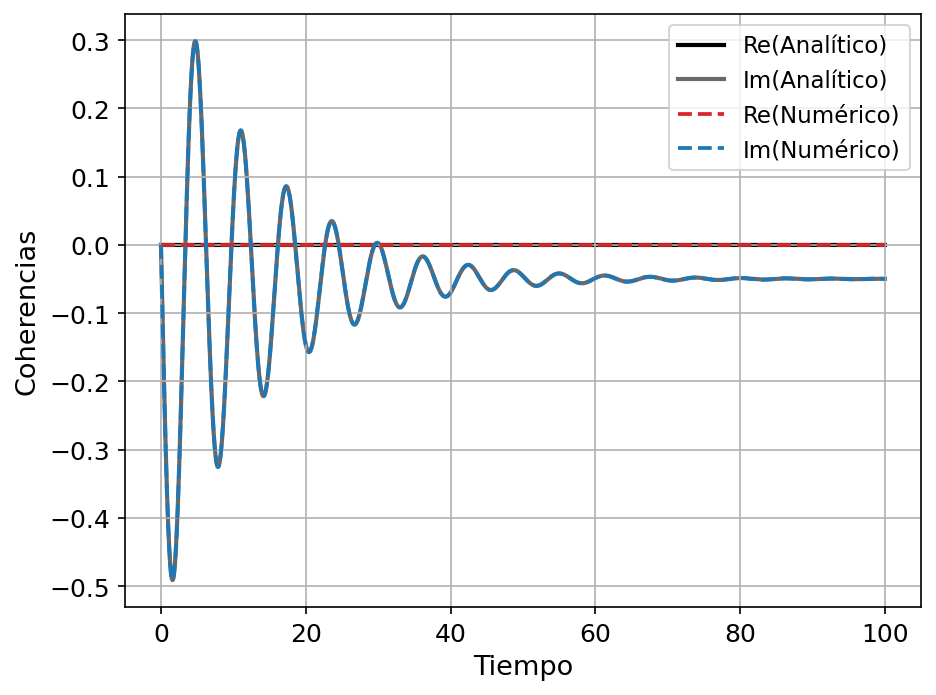


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.000000
Im Numérico: -0.049718
Re Analítico: 0.000000
Im Analítico: -0.049582


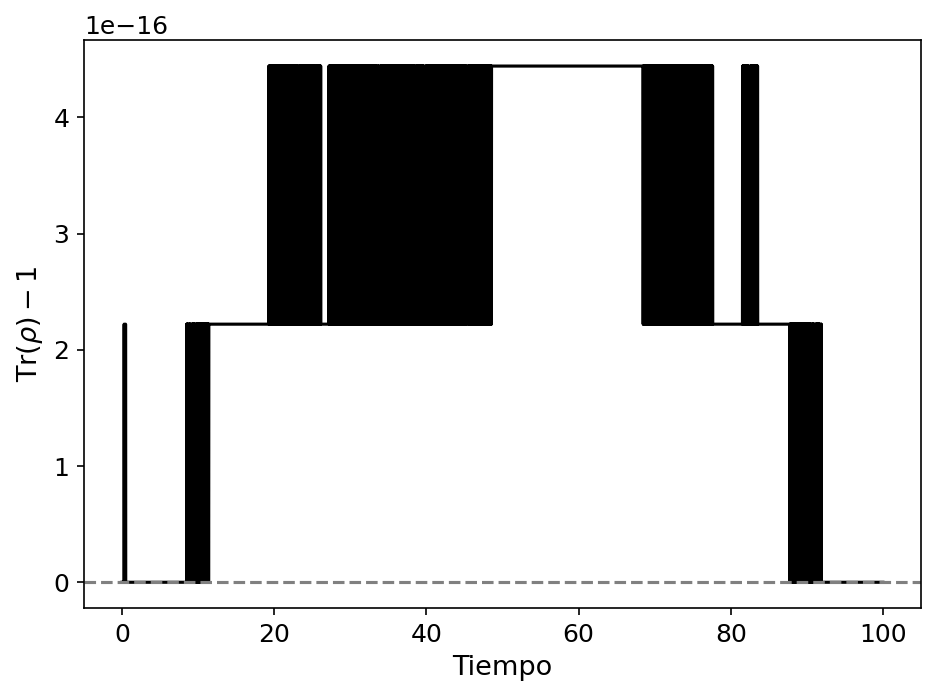


=== TRAZA ===
Máximo error: 4.441e-16


In [ ]:
#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# analítico (referencia)
plt.plot(t, y, label="Analítico | e", linewidth=2, color='black', zorder=1)
plt.plot(t, 1 - y, label="Analítico | g", linewidth=2, color='dimgray', zorder=1)

# numérico (comparación)
plt.plot(t, Mdensity_ee, '--', label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, '--', label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")
print(f"Analítico | e: {y[-1]:.6f}")
print(f"Analítico | g: {(1 - y)[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# analítico
plt.plot(t, np.real(z), label="Re(Analítico)", linewidth=2, color='black', zorder=1)
plt.plot(t, np.imag(z), label="Im(Analítico)", linewidth=2, color='dimgray', zorder=1)

# numérico
plt.plot(t, Mdensity_eg_real, '--', label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, '--', label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")
print(f"Re Analítico: {np.real(z)[-1]:.6f}")
print(f"Im Analítico: {np.imag(z)[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1       #Ya que la traza de la matriz densidad debe ser igual a 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

En segundo lugar, se analizamos el caso donde $\frac{\gamma_{0}}{\Omega} = 0.5$ tenemos:

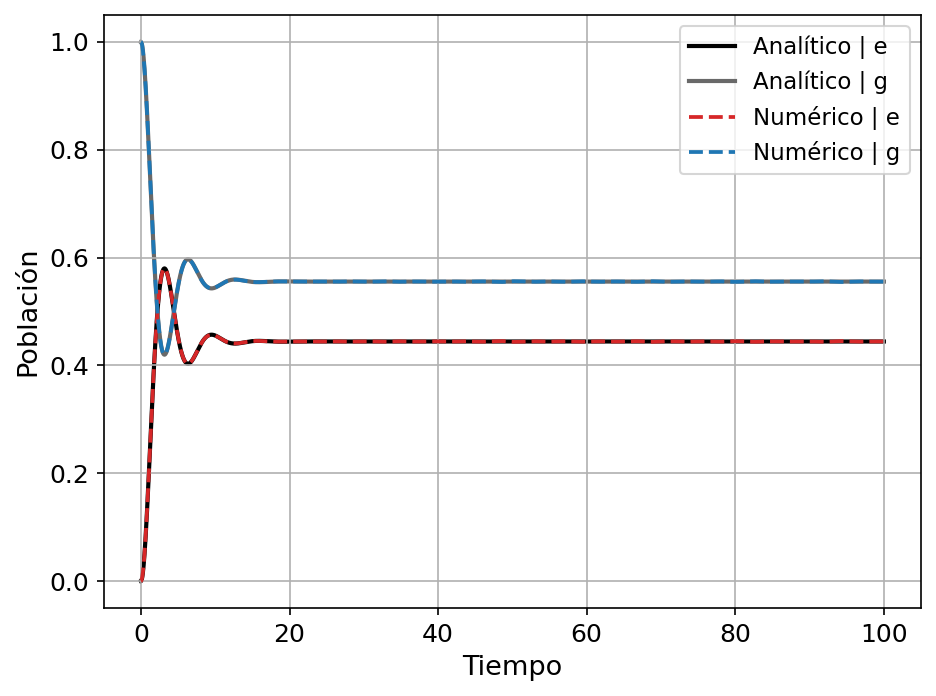


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.444491
Numérico | g: 0.555509
Analítico | e: 0.444444
Analítico | g: 0.555556


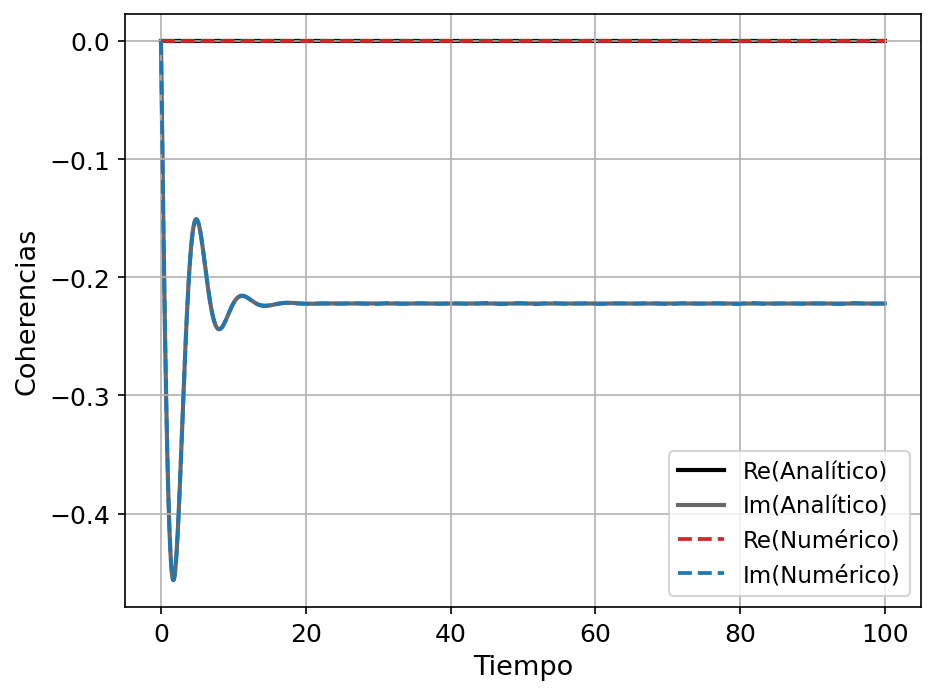


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.000000
Im Numérico: -0.222203
Re Analítico: 0.000000
Im Analítico: -0.222222


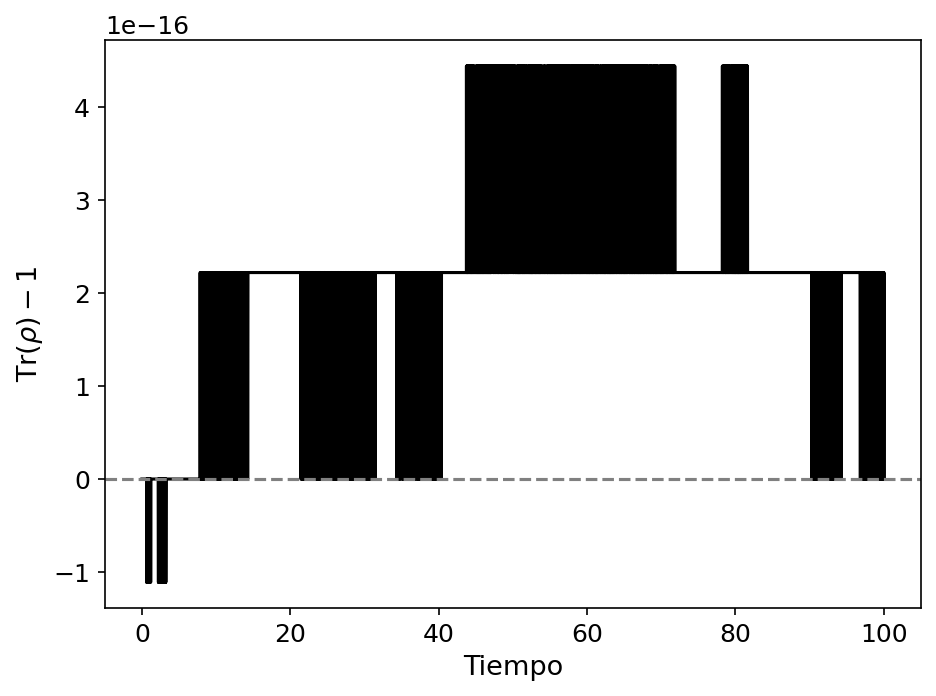


=== TRAZA ===
Máximo error: 4.441e-16


In [20]:
Gamma=0.5*Omega
rates=[Gamma]

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Poblacion excitada Analitica si detuning

mu = np.sqrt(Omega**2 - (Gamma/4)**2)

def p_ee(t):
    A = (Omega**2) / (Gamma**2 + 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + (3*Gamma/(4*mu))*np.sin(mu*t))
    )

y = p_ee(t)

def p_eg(t):
    A = ( -1j*Omega*Gamma ) / ( Gamma**2+ 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + ((Gamma/(4*mu))-(Omega**2/(mu*Gamma)))*np.sin(mu*t))
    )

z = p_eg(t)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# analítico (referencia)
plt.plot(t, y, label="Analítico | e", linewidth=2, color='black', zorder=1)
plt.plot(t, 1 - y, label="Analítico | g", linewidth=2, color='dimgray', zorder=1)

# numérico (comparación)
plt.plot(t, Mdensity_ee, '--', label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, '--', label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")
print(f"Analítico | e: {y[-1]:.6f}")
print(f"Analítico | g: {(1 - y)[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# analítico
plt.plot(t, np.real(z), label="Re(Analítico)", linewidth=2, color='black', zorder=1)
plt.plot(t, np.imag(z), label="Im(Analítico)", linewidth=2, color='dimgray', zorder=1)

# numérico
plt.plot(t, Mdensity_eg_real, '--', label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, '--', label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")
print(f"Re Analítico: {np.real(z)[-1]:.6f}")
print(f"Im Analítico: {np.imag(z)[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Por ultimo, tenemos el caso donde la disipacion es muy alta, tal que $\frac{\gamma_{0}}{\Omega} = 1$:

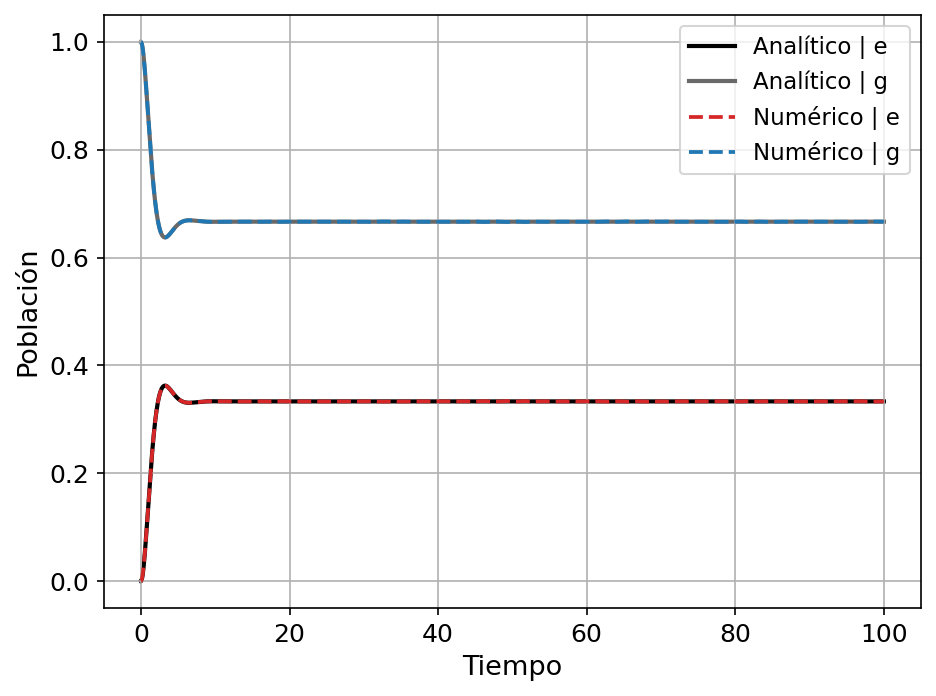


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.333286
Numérico | g: 0.666714
Analítico | e: 0.333333
Analítico | g: 0.666667


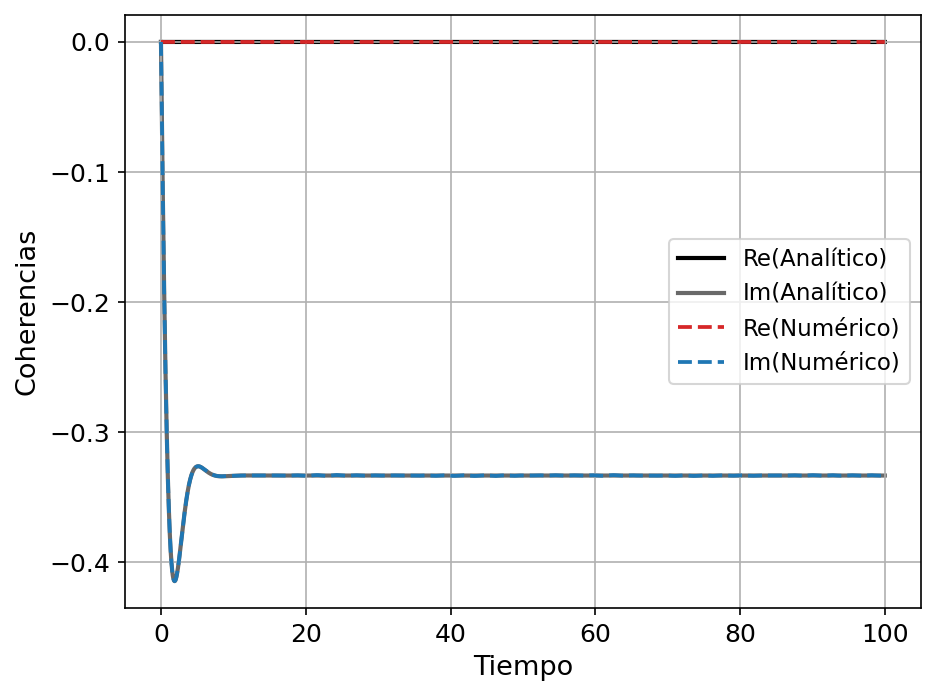


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.000000
Im Numérico: -0.333433
Re Analítico: 0.000000
Im Analítico: -0.333333


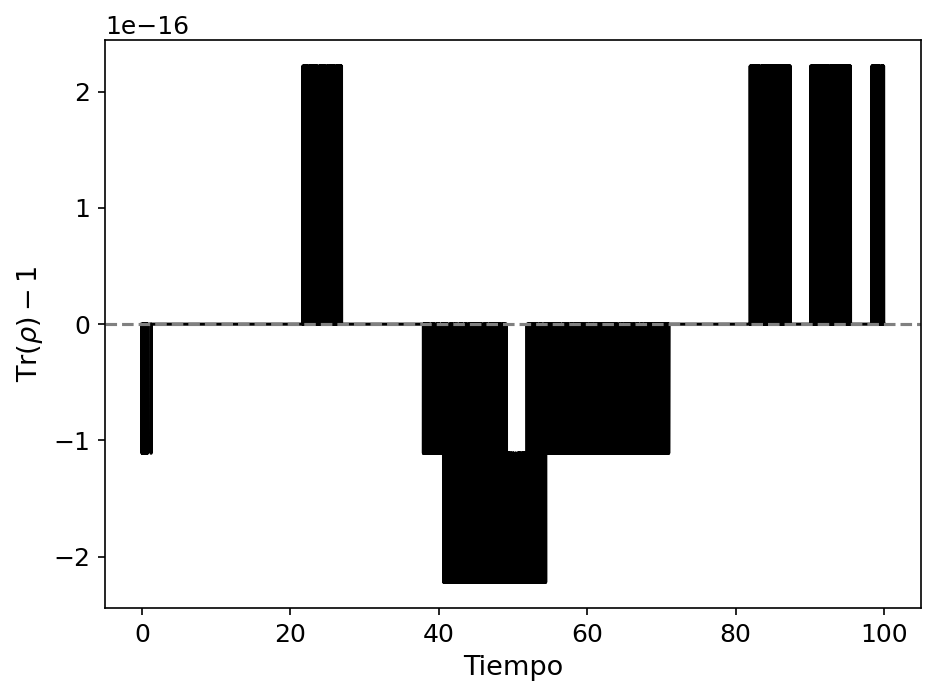


=== TRAZA ===
Máximo error: 2.220e-16


In [21]:
Gamma=Omega
rates=[Gamma]

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Poblacion excitada Analitica si detuning

mu = np.sqrt(Omega**2 - (Gamma/4)**2)

def p_ee(t):
    A = (Omega**2) / (Gamma**2 + 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + (3*Gamma/(4*mu))*np.sin(mu*t))
    )

y = p_ee(t)

def p_eg(t):
    A = ( -1j*Omega*Gamma ) / ( Gamma**2+ 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + ((Gamma/(4*mu))-(Omega**2/(mu*Gamma)))*np.sin(mu*t))
    )

z = p_eg(t)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# analítico (referencia)
plt.plot(t, y, label="Analítico | e", linewidth=2, color='black', zorder=1)
plt.plot(t, 1 - y, label="Analítico | g", linewidth=2, color='dimgray', zorder=1)

# numérico (comparación)
plt.plot(t, Mdensity_ee, '--', label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, '--', label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")
print(f"Analítico | e: {y[-1]:.6f}")
print(f"Analítico | g: {(1 - y)[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# analítico
plt.plot(t, np.real(z), label="Re(Analítico)", linewidth=2, color='black', zorder=1)
plt.plot(t, np.imag(z), label="Im(Analítico)", linewidth=2, color='dimgray', zorder=1)

# numérico
plt.plot(t, Mdensity_eg_real, '--', label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, '--', label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")
print(f"Re Analítico: {np.real(z)[-1]:.6f}")
print(f"Im Analítico: {np.imag(z)[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Con esto podemos concluir que la implementacion numerica es correcta. Ahora queremos analizar cual es el rol del detuning $\delta$ para valores fijos de $\frac{\gamma_{0}}{\Omega}$. Se fija $\frac{\gamma_{0}}{\Omega}=0.1$ y comenzamos con un detuning $\delta=0.1$:

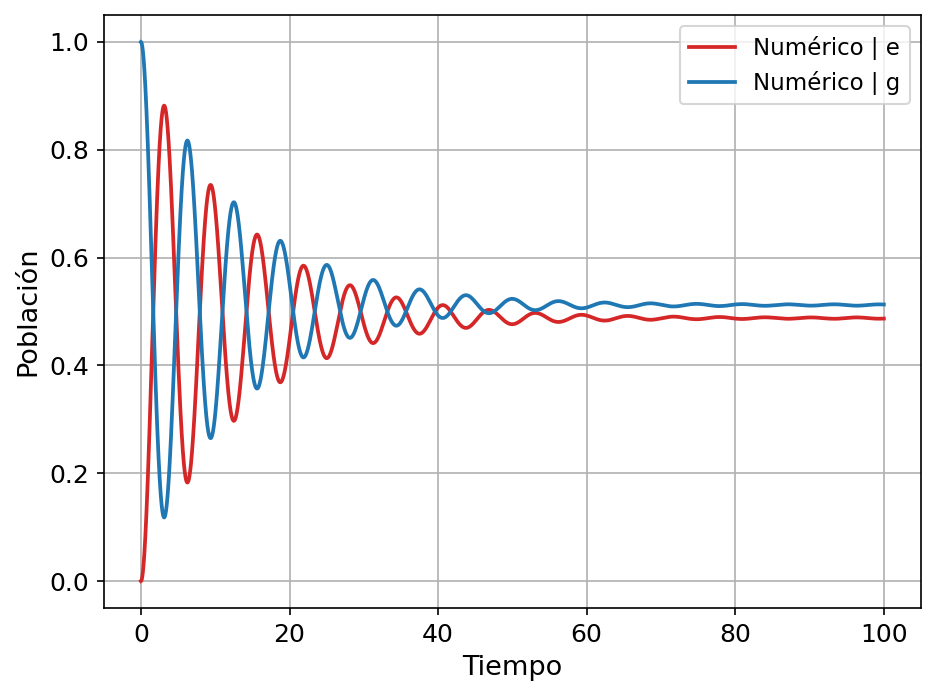


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.486947
Numérico | g: 0.513053


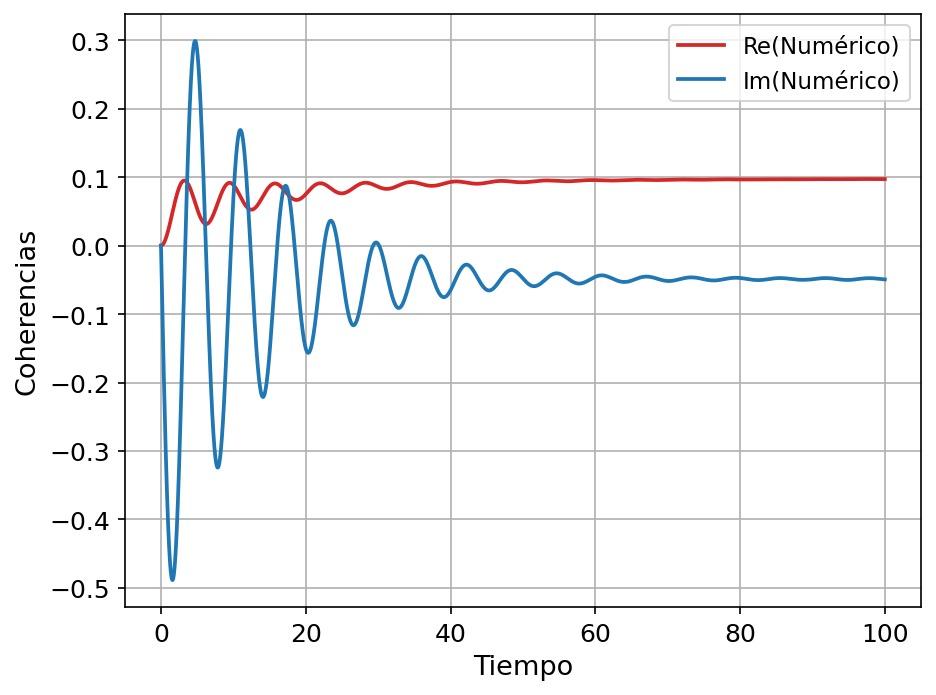


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.097158
Im Numérico: -0.049393


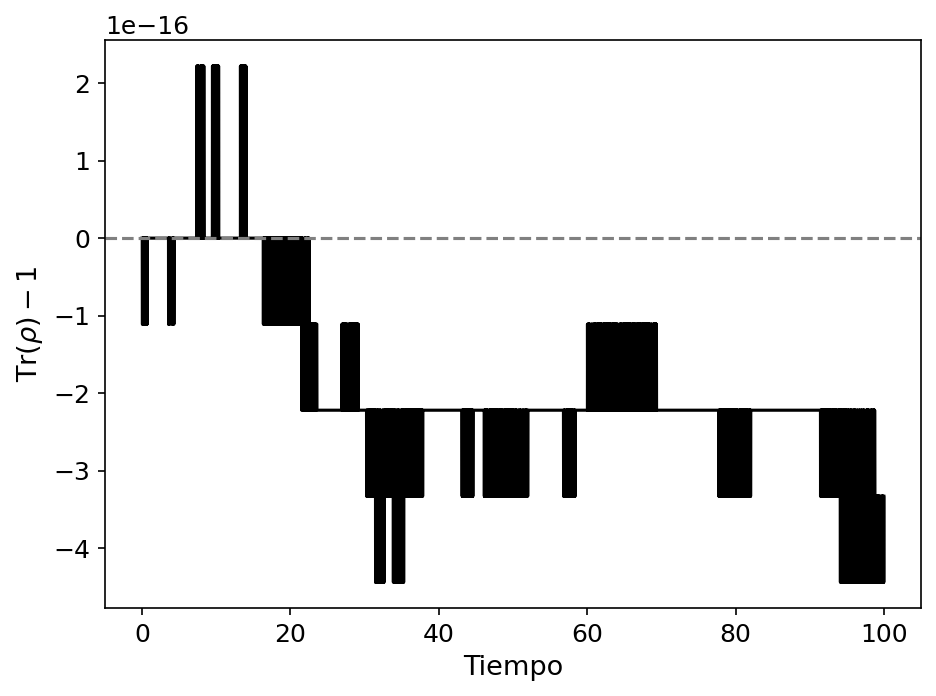


=== TRAZA ===
Máximo error: 4.441e-16


In [24]:
Gamma=0.1*Omega
delta=0.1
rates=[Gamma]

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# numérico (comparación)
plt.plot(t, Mdensity_ee, label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# numérico
plt.plot(t, Mdensity_eg_real, label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Procedemos con el segundo caso, donde $\delta=0.25$:

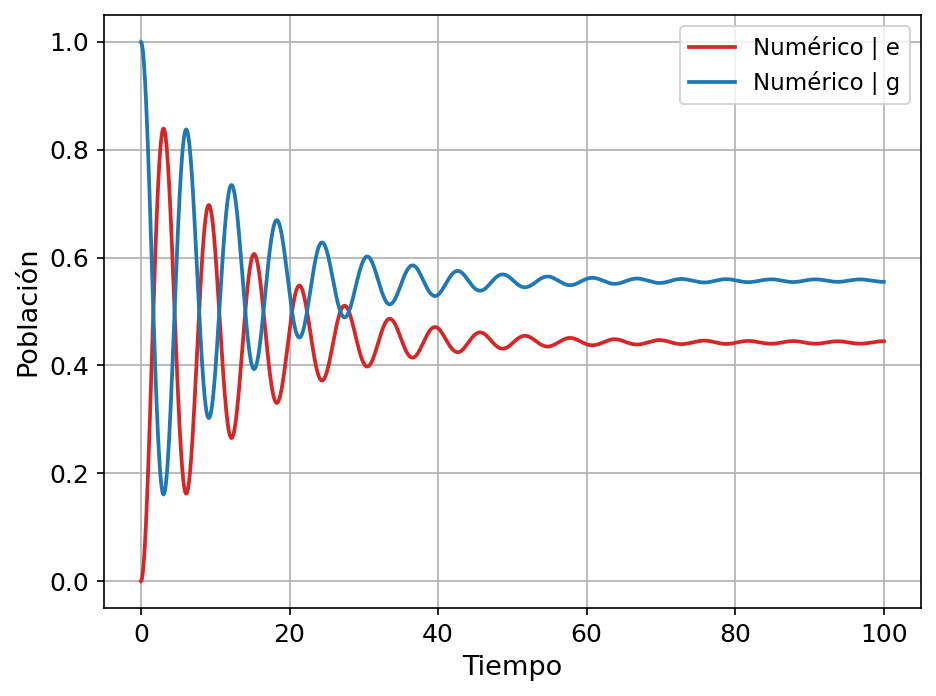


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.444846
Numérico | g: 0.555154


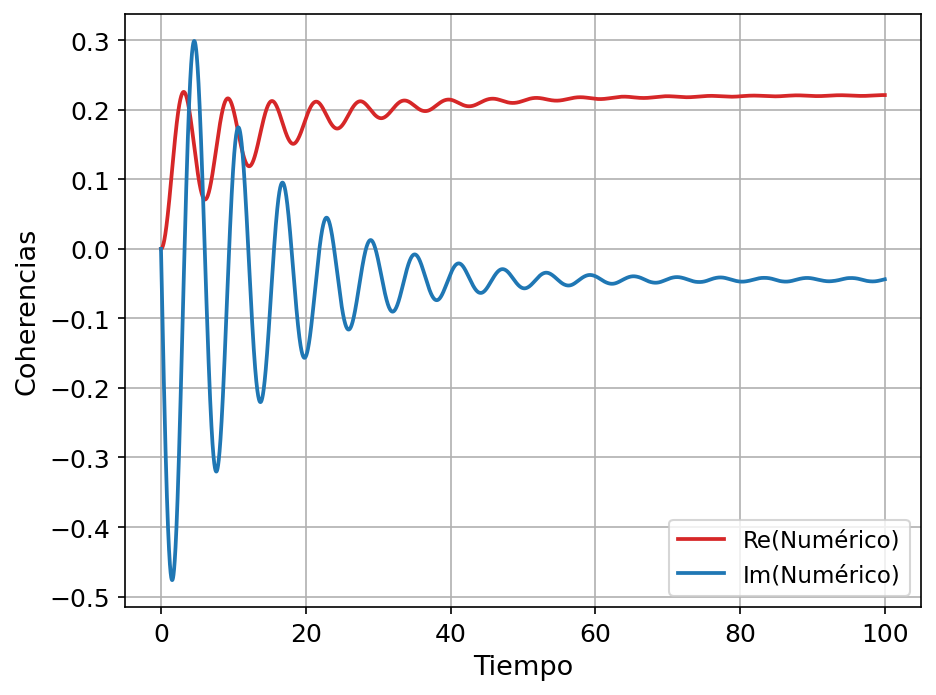


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.221280
Im Numérico: -0.043679


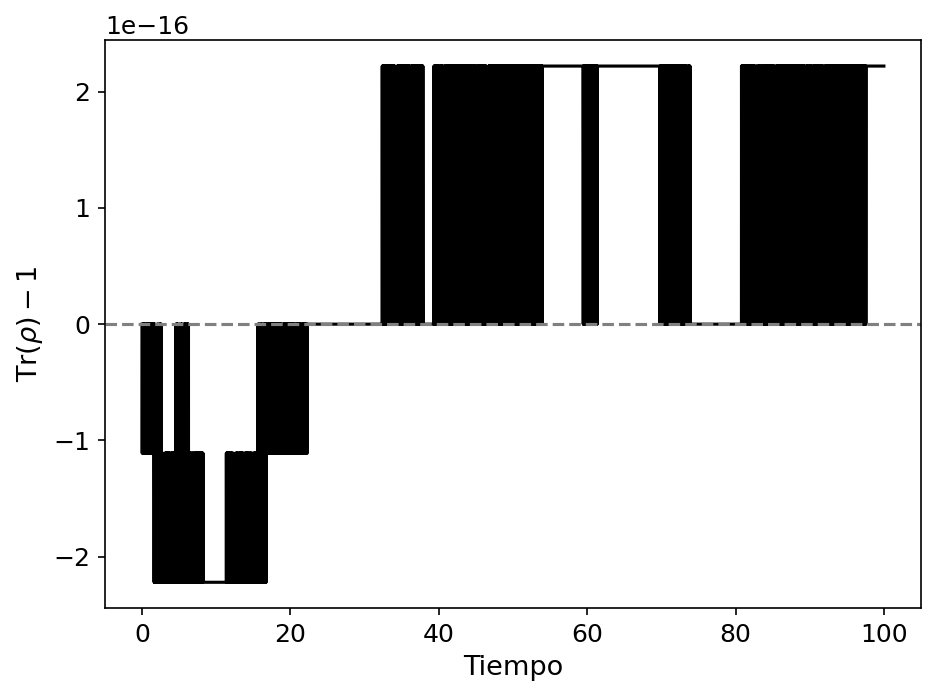


=== TRAZA ===
Máximo error: 2.220e-16


In [25]:
Gamma=0.1*Omega
delta=0.25
rates=[Gamma]

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# numérico (comparación)
plt.plot(t, Mdensity_ee, label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# numérico
plt.plot(t, Mdensity_eg_real, label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Por ultimo, analizamos cuando $\delta=0.5$:

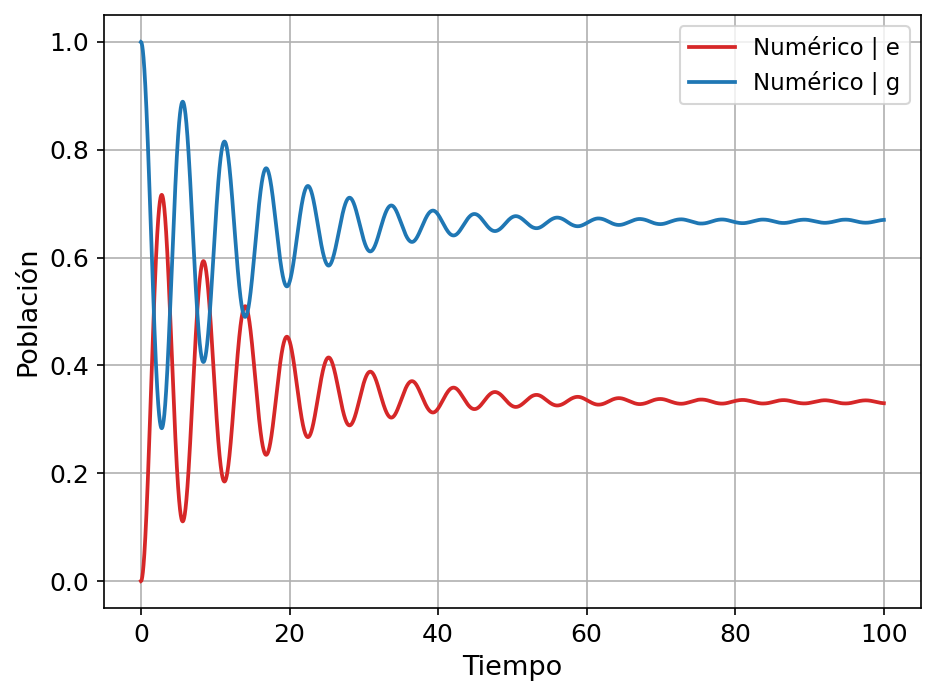


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.329952
Numérico | g: 0.670048


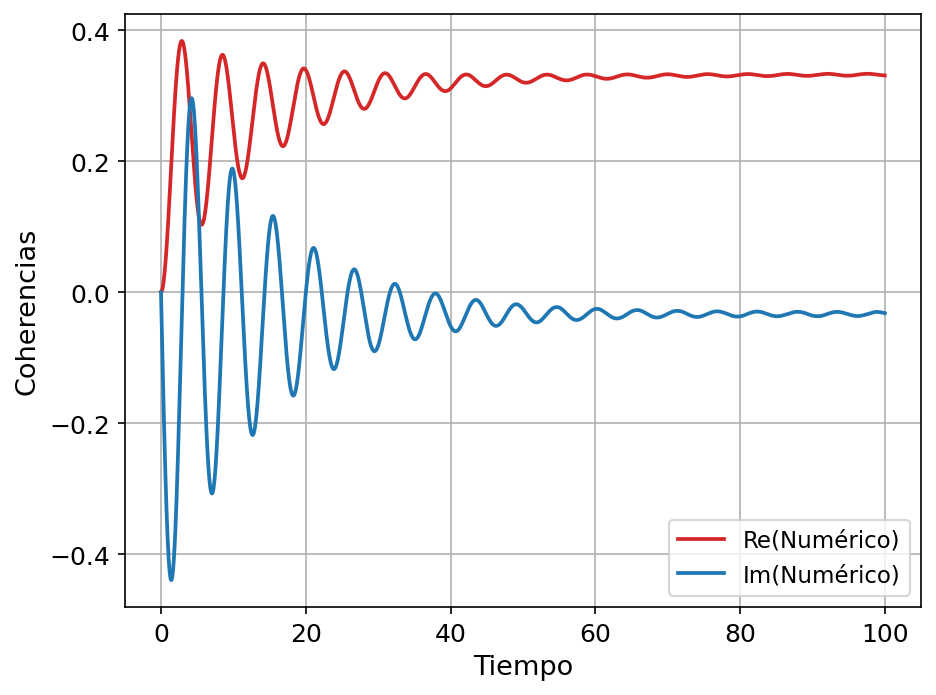


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.330698
Im Numérico: -0.032073


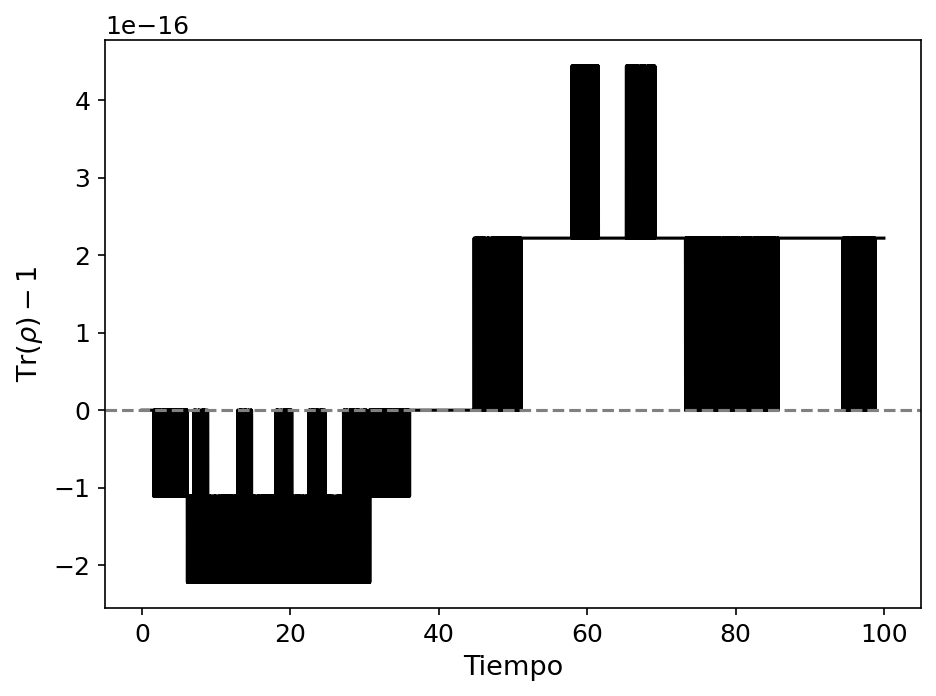


=== TRAZA ===
Máximo error: 4.441e-16


In [26]:
Gamma=0.1*Omega
delta=0.5
rates=[Gamma]

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# numérico (comparación)
plt.plot(t, Mdensity_ee, label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# numérico
plt.plot(t, Mdensity_eg_real, label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Ahora hacemos lo mismo pero para $\frac{\gamma_{0}}{\Omega}=0.5$:

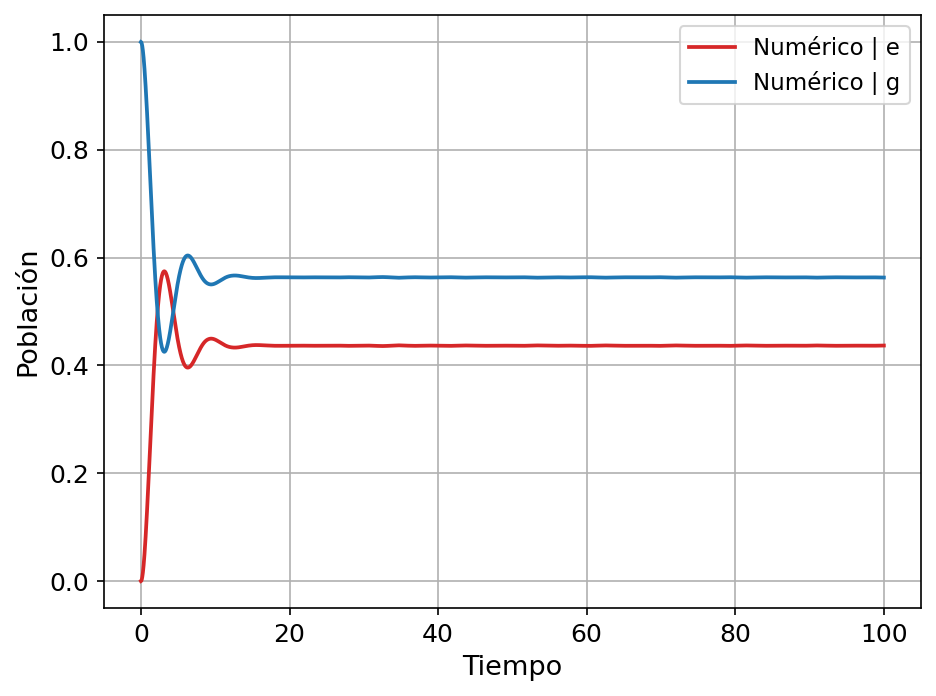


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.436945
Numérico | g: 0.563055


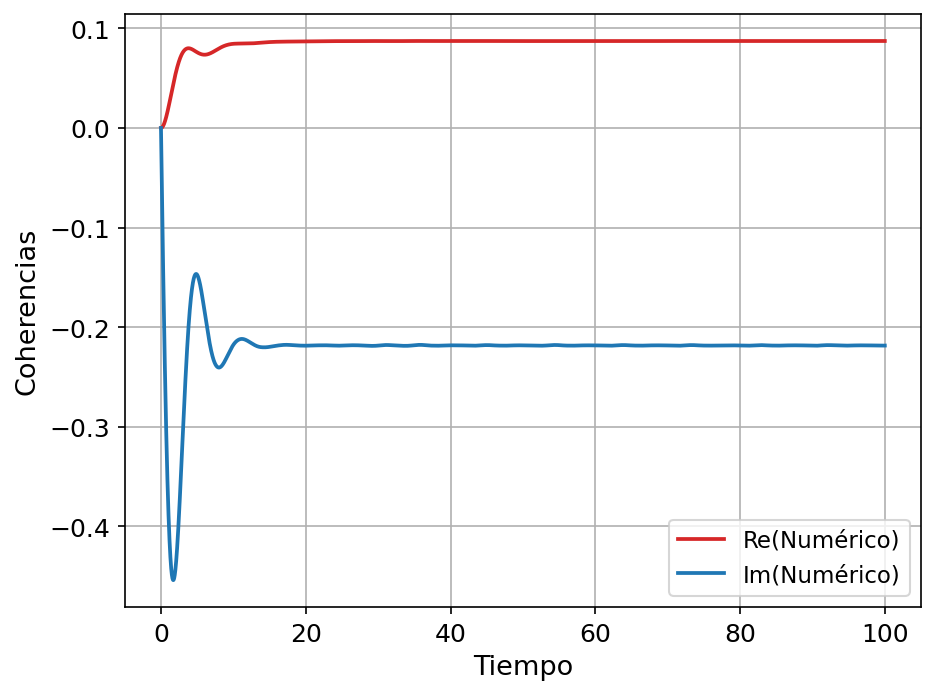


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.087359
Im Numérico: -0.218468


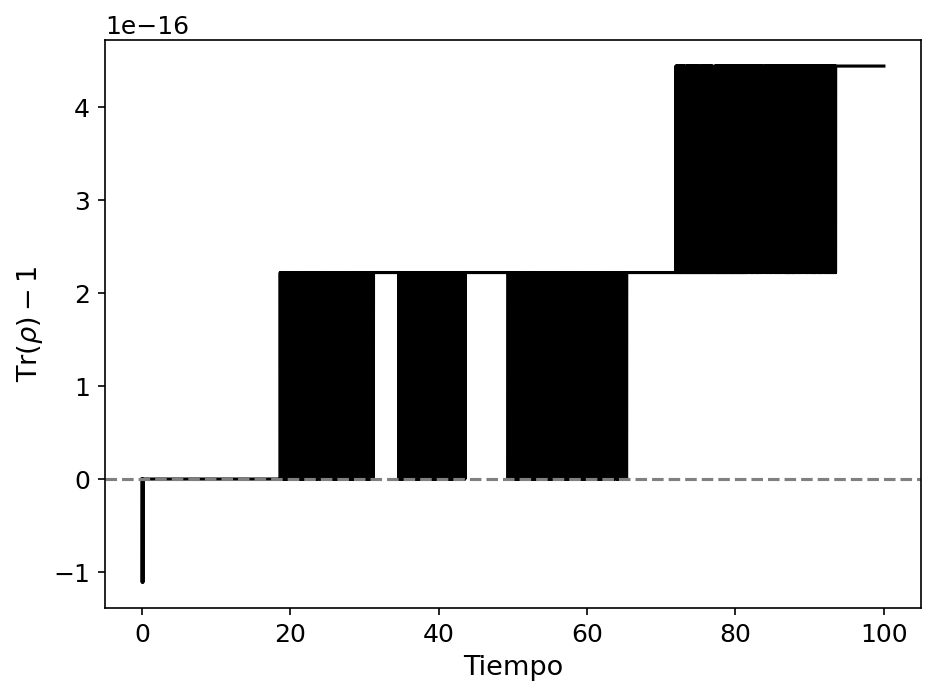


=== TRAZA ===
Máximo error: 4.441e-16


In [28]:
Gamma=0.5*Omega
delta=0.1
rates=[Gamma]

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# numérico (comparación)
plt.plot(t, Mdensity_ee, label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# numérico
plt.plot(t, Mdensity_eg_real, label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")

Ahora con $\delta=0.25$:

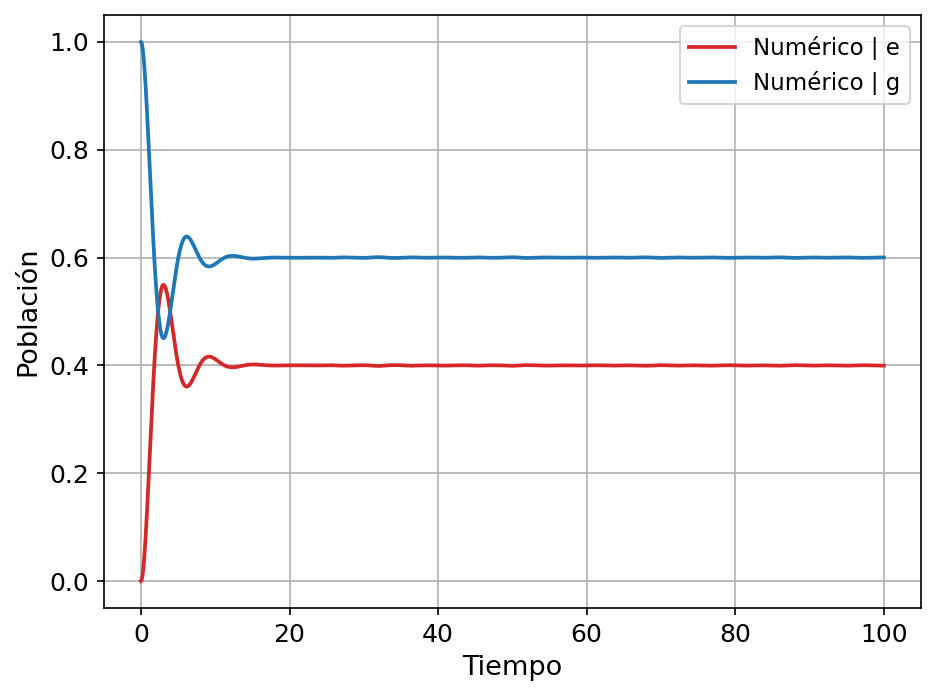


=== VALORES FINALES (POBLACIONES) ===
Numérico | e: 0.399721
Numérico | g: 0.600279


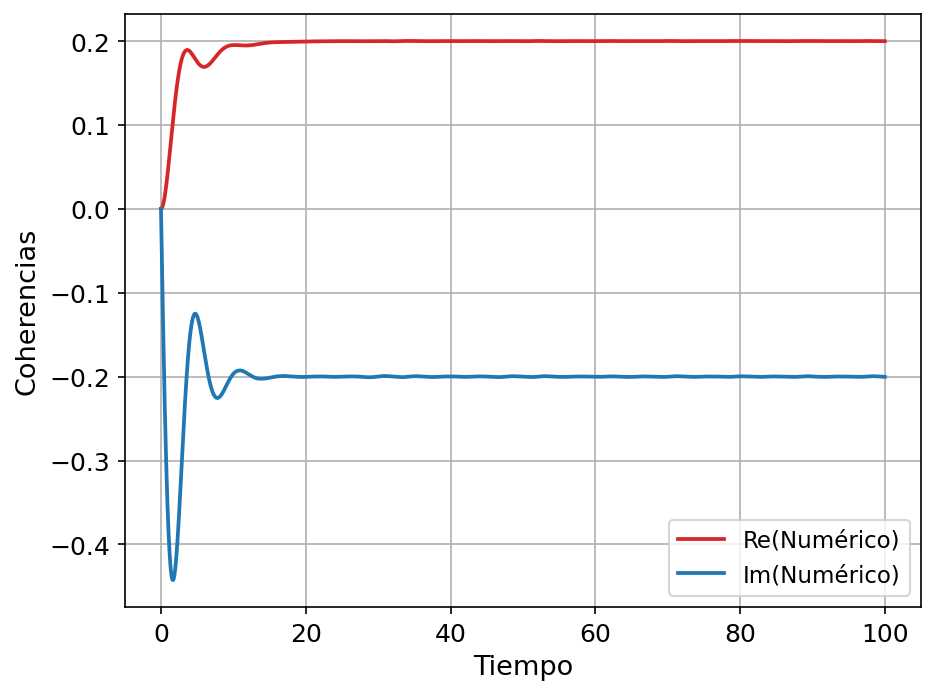


=== VALORES FINALES (COHERENCIAS) ===
Re Numérico: 0.199914
Im Numérico: -0.200265


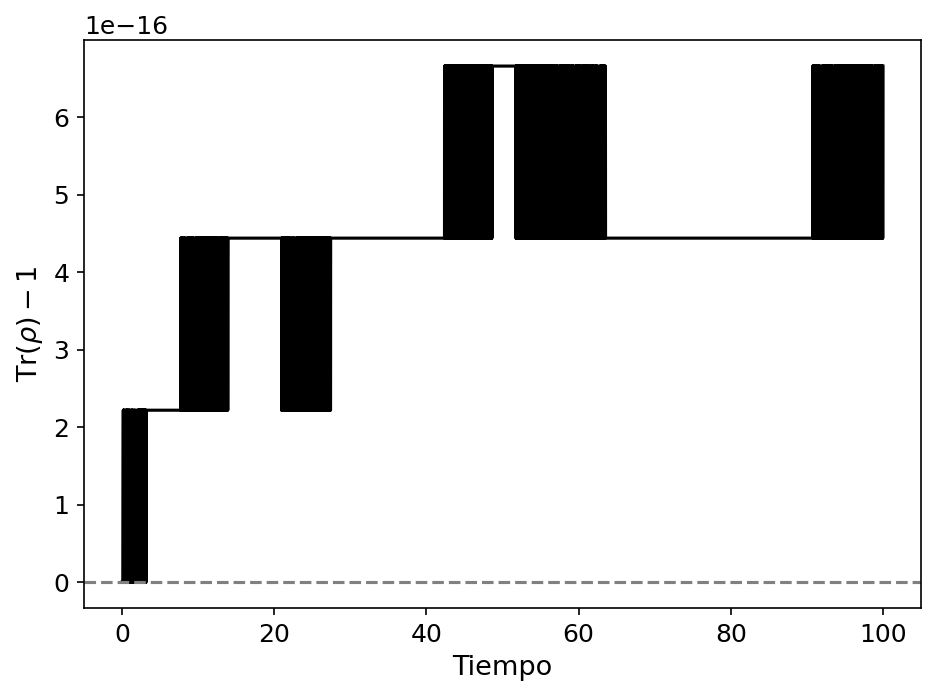


=== TRAZA ===
Máximo error: 6.661e-16


In [35]:
Gamma=0.5*Omega
delta=0.25
rates=[Gamma]

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Solucion

sol= solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=np.linspace(0,100,10000), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# numérico (comparación)
plt.plot(t, Mdensity_ee, label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (POBLACIONES) ===")
print(f"Numérico | e: {Mdensity_ee[-1]:.6f}")
print(f"Numérico | g: {Mdensity_gg[-1]:.6f}")

# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# numérico
plt.plot(t, Mdensity_eg_real, label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VALORES FINALES (COHERENCIAS) ===")
print(f"Re Numérico: {Mdensity_eg_real[-1]:.6f}")
print(f"Im Numérico: {Mdensity_eg_imag[-1]:.6f}")

#Verificando traza

error_trace = Mdensity_ee + Mdensity_gg - 1

plt.figure()
plt.plot(t, error_trace, color='black', linewidth=1.5)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Tr}(\rho)-1$")

plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.grid()
plt.tight_layout()
plt.show()

print("\n=== TRAZA ===")
print(f"Máximo error: {np.max(np.abs(error_trace)):.3e}")